In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tabulate import tabulate

### Recording tasks

- Speakers: 162
- Task lists:
    - set A: 30 prompts, used in drunk sessions
    - set NA: 60 prompts, used in sober sessions

The chosen task set depends on the type of session (drunk or sober).
If session number begins with:
- 1 or 3, then set A
- 2 or 4, then set NA 

Important! The task IDs from set A ARE NOT the same as set NA

#### Format of the recording's name:

![Recording Name Format](../RecordingNameFormat.jpg)


5863087001_h_00.wav
- speaker: 586
- session: 3087
- taskID: 001 (from set A)

## Count of tasks types

In [61]:
#Loading Task Prompts
task_folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\DrunkenLinguists\inebriation-voice-detector")
task_file = os.path.join(task_folder, 'TaskACL.xlsx')
drunk_tasks = pd.read_excel(task_file, sheet_name='Drunk tasks')
sober_tasks = pd.read_excel(task_file, sheet_name='Sober tasks')

#Changig column names
drunk_tasks = drunk_tasks.rename(columns={
    'Merge task ID': 'Merge ID',
    'Type': 'Type',
    'Subtype': 'Subtype'
})

sober_tasks = sober_tasks.rename(columns={
    'Merge task ID': 'Merge ID',
    'Type': 'Type',
    'Subtype': 'Subtype'
})


# Combine task metadata: task ID (Merge Task ID), type, and subtype
task_metadata = pd.concat([drunk_tasks[['Merge ID', 'Type', 'Subtype']],
                           sober_tasks[['Merge ID', 'Type', 'Subtype']]]).drop_duplicates(subset=["Merge ID"])


In [62]:
# Count of type of prompts in the drunk tasks set
drunk_counts = drunk_tasks.groupby(['Type', 'Subtype']).size().reset_index(name='Count')
print("COUNT OF TYPE OF PROMPTS IN THE DRUNK TASKS SET")
print(drunk_counts)

COUNT OF TYPE OF PROMPTS IN THE DRUNK TASKS SET
             Type                Subtype  Count
0   Open question      Describe an image      3
1   Open question        Issue a command      5
2   Open question           Tell a story      2
3         Reading        Rapid word list      2
4         Reading         Read a command      3
5         Reading   Read a license plate      1
6         Reading          Read a number      4
7         Reading     Read a temperature      1
8         Reading  Read a tongue twister      3
9         Reading        Read an address      5
10        Reading           Spell a word      1


In [63]:
# Count of type of prompts in the sober tasks set
sober_counts = sober_tasks.groupby(['Type', 'Subtype']).size().reset_index(name='Count')
print("COUNT OF TYPE OF PROMPTS IN THE SOBER TASKS SET")
print(sober_counts)

COUNT OF TYPE OF PROMPTS IN THE SOBER TASKS SET
             Type                Subtype  Count
0   Open question      Describe an image      6
1   Open question        Issue a command     10
2   Open question           Tell a story      4
3         Reading        Rapid word list      2
4         Reading         Read a command      8
5         Reading   Read a license plate      2
6         Reading          Read a number      8
7         Reading     Read a temperature      1
8         Reading  Read a tongue twister      8
9         Reading        Read an address     10
10        Reading           Spell a word      1


## Analyzing list of recordings

In [64]:
folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC")

#CSV file with the list of recordings
inputTrain_file = 'spectrogram_listTrain.csv'
inputTest_file = 'spectrogram_listTest.csv'
inputVal_file = 'spectrogram_listVal.csv'

#Full path to the CSV file
full_pathTrain = os.path.join(folder, inputTrain_file)
full_pathTest = os.path.join(folder, inputTest_file)
full_pathVal = os.path.join(folder, inputVal_file)

#Reading the CSV file
recording_listTrain = pd.read_csv(full_pathTrain)
recording_listTest = pd.read_csv(full_pathTest)
recording_listVal = pd.read_csv(full_pathVal)

"""File structure:
    0: File name
    1: label
    2: BAC
    3: Task set
    4: Task ID
"""
#Renaming columns
columns = ['File name', 'Label', 'BAC', 'Task Set', 'Task ID','Merge ID']
recording_listTrain.columns = columns
recording_listTest.columns = columns
recording_listVal.columns = columns

#Adding a column to identify the task ID
#recording_listTrain['Merge task ID'] = recording_listTrain.apply(map_merge_id, axis=1)
#recording_listTest['Merge task ID'] = recording_listTest.apply(map_merge_id, axis=1)
#recording_listVal['Merge task ID'] = recording_listVal.apply(map_merge_id, axis=1)

In [65]:
print(recording_listTrain['Merge ID'].unique())

[46 30  4 41 55 13 23 34 42 12 45 38 31  1 18 40 61 15 60 37 22 57 20 39
 26  7 36 50 52 32 17 10  5 48 16 24 59 14 51 11 19 35 29 56 49 28 27  8
 33  9 44  2 21 54 25  6 43 58 53 47  3]


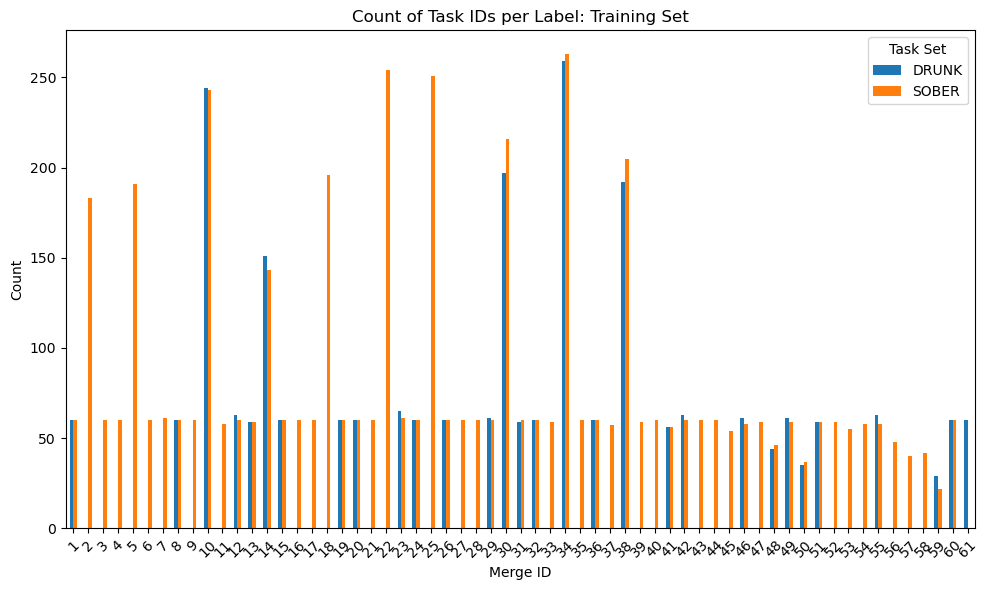

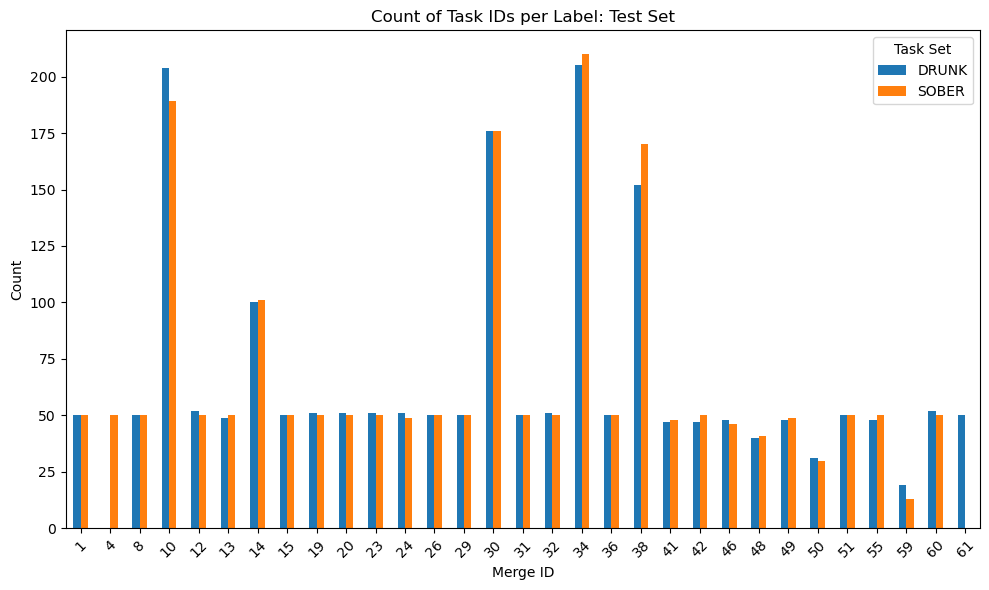

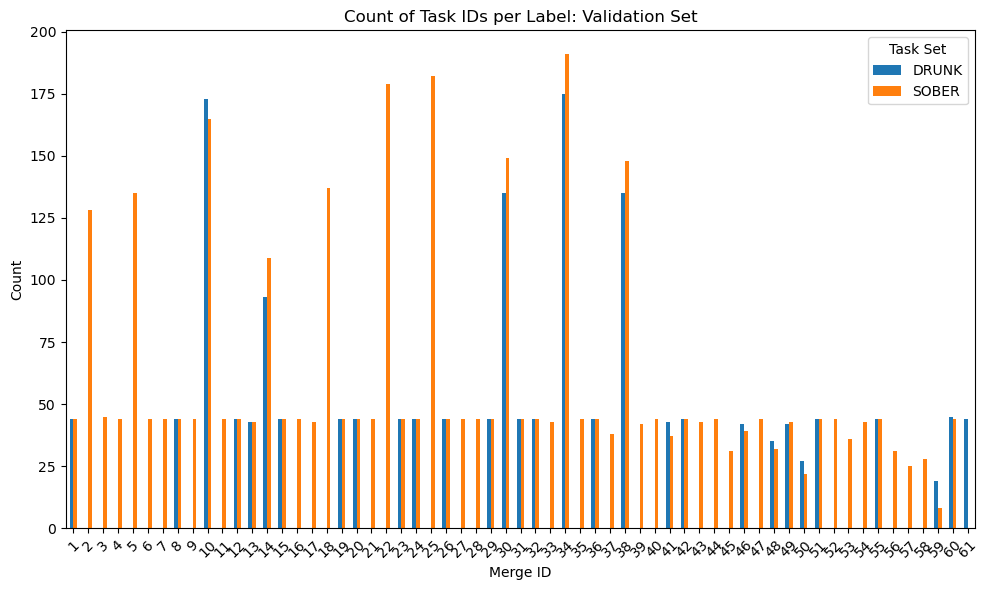

In [66]:
# Count of Drunk and Sober recordings in each recording list
pivot_tableTrain = recording_listTrain.pivot_table(
    index='Merge ID',
    columns='Task Set',
    aggfunc='size',
    fill_value=0
)

pivot_tableTest = recording_listTest.pivot_table(
    index='Merge ID',
    columns='Task Set',
    aggfunc='size',
    fill_value=0
)

pivot_tableVal = recording_listVal.pivot_table(
    index='Merge ID',
    columns='Task Set',
    aggfunc='size',
    fill_value=0
)

#print(pivot_tableTrain)

# Plot the pivot table
pivot_tableTrain.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Task IDs per Label: Training Set')
plt.xlabel('Merge ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Task Set')
plt.tight_layout()
plt.show()

pivot_tableTest.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Task IDs per Label: Test Set')
plt.xlabel('Merge ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Task Set')
plt.tight_layout()
plt.show()

pivot_tableVal.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Task IDs per Label: Validation Set')
plt.xlabel('Merge ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Task Set')
plt.tight_layout()
plt.show()

In [67]:
filtered_df = recording_listTrain[(recording_listTrain['Label'] == 0) & (recording_listTrain['Task Set'].str.upper() == 'DRUNK')]
print(tabulate(filtered_df[['File name','Label','BAC']], headers='keys', tablefmt='grid'))

##Note: there are recordings where the BAC value is low, so the label is 0, but the task set is DRUNK.

+------+-----------------------------------------------------------------------------------------------------+---------+---------+
|      | File name                                                                                           |   Label |     BAC |
+======+=====================================================================================================+=========+=========+
|  100 | c:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\0241025017_h_00.wav_0_0.jpg |       0 | 0.00023 |
+------+-----------------------------------------------------------------------------------------------------+---------+---------+
|  343 | c:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\5813082020_h_00.wav_0_0.jpg |       0 | 0.00049 |
+------+-----------------------------------------------------------------------------------------------------+---------+---------+
|  354 | c:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\50

In [68]:
#Merge with task metadata
merged_dfTrain = recording_listTrain.merge(task_metadata, on='Merge ID', how='left')
merged_dfTest = recording_listTest.merge(task_metadata, on='Merge ID', how='left')
merged_dfVal = recording_listVal.merge(task_metadata, on='Merge ID', how='left')


In [69]:
print(merged_dfTrain['Merge ID'].unique())
print(task_metadata['Merge ID'].unique())
print(merged_dfTrain.shape)
# Count unique Subtypes per Merge ID
print(recording_listTrain.groupby('Merge ID')['Merge ID'].nunique().value_counts())
print(task_metadata.groupby('Merge ID')['Subtype'].nunique().value_counts())
print(merged_dfTrain.groupby('Merge ID')['Subtype'].nunique().value_counts())


[46 30  4 41 55 13 23 34 42 12 45 38 31  1 18 40 61 15 60 37 22 57 20 39
 26  7 36 50 52 32 17 10  5 48 16 24 59 14 51 11 19 35 29 56 49 28 27  8
 33  9 44  2 21 54 25  6 43 58 53 47  3]
[ 1 34 32 61 30 26 23  8 29 10 31 12 13 14 15 36 24 38 19 20 41 42 59 51
 46 55 48 49 50 60  2  3  4  5  6  7  9 11 16 17 18 21 22 25 27 28 33 35
 37 39 40 43 44 45 47 52 53 54 56 57 58]
(7470, 8)
Merge ID
1    61
Name: count, dtype: int64
Subtype
1    61
Name: count, dtype: int64
Subtype
1    61
Name: count, dtype: int64


In [70]:
#Count of type of task acording to label

def barplot_label(df,title,hue,x_axis):
    if hue == 'Task Set':
        label_order=sorted(df[hue].unique(),reverse=True)
    else:
        label_order=sorted(df[hue].unique(),reverse=False)
    plt.figure(figsize=(10,6))
    sns.barplot(data=df, x=x_axis, y='Count', hue=hue,hue_order=label_order)

    plt.title('Count of Task Types per {}: {}'.format(hue,title))
    plt.xlabel('Task Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title=hue)
    plt.tight_layout()
    plt.show()

def count_type_label(df,title):
    print(title.upper())
    print("\nCOUNT OF TYPE OF TASK ACCORDING TO LABEL")
    type_counts = df.groupby(['Label','Type']).size().reset_index(name='Count')
    pivot_type_counts = type_counts.pivot_table(index='Type', columns='Label', values='Count', 
                                            fill_value=0).reset_index()
    print(pivot_type_counts)

    type_counts.sort_values(by='Type', ascending=True, inplace=True)
    barplot_label(type_counts,title,'Label','Type')

    print("\nCOUNT OF TYPE OF TASK ACCORDING TO TASK SET")
    type_counts = df.groupby(['Task Set', 'Type']).size().reset_index(name='Count')
    pivot_type_counts = type_counts.pivot_table(index='Type', columns='Task Set', values='Count', 
                                            fill_value=0).reset_index()
    print(pivot_type_counts)

    barplot_label(type_counts,title,'Task Set','Type')

def barplot_subtype(df,hue):
    if hue == 'Task Set':
        label_order=sorted(df[hue].unique(),reverse=True)
    else:
        label_order=sorted(df[hue].unique(),reverse=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=df, x='Subtype', y='Count', hue=hue, hue_order=label_order)

    plt.title('Count of Task Subtypes per {}:'.format(hue))
    plt.xlabel('Task Subtype')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title=hue)
    plt.tight_layout()
    plt.show()

def count_type_sublabel(df,title):
    print("\nCOUNT OF SUBTYPE OF TASK ACCORDING TO LABEL")
    subtype_counts = df.groupby(['Label', 'Type', 'Subtype']).size().reset_index(name='Count')

    pivot_counts = subtype_counts.pivot_table(index=['Type', 'Subtype'], 
                                            columns='Label', 
                                            values='Count', 
                                            fill_value=0).reset_index()

    print(pivot_counts)

    subtype_counts.sort_values(by='Subtype', ascending=True, inplace=True)
    barplot_subtype(subtype_counts,'Label')

    print("\nCOUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET")
    subtype_counts = df.groupby(['Task Set', 'Type', 'Subtype']).size().reset_index(name='Count')

    pivot_counts = subtype_counts.pivot_table(index=['Type', 'Subtype'], 
                                            columns='Task Set', 
                                            values='Count', 
                                            fill_value=0).reset_index()

    print(pivot_counts)
    
    subtype_counts.sort_values(by='Subtype', ascending=True, inplace=True)
    barplot_subtype(subtype_counts,'Task Set')



TRAINING SET

COUNT OF TYPE OF TASK ACCORDING TO LABEL
Label           Type       0       1
0      Open question  2817.0  1230.0
1            Reading  2372.0  1051.0


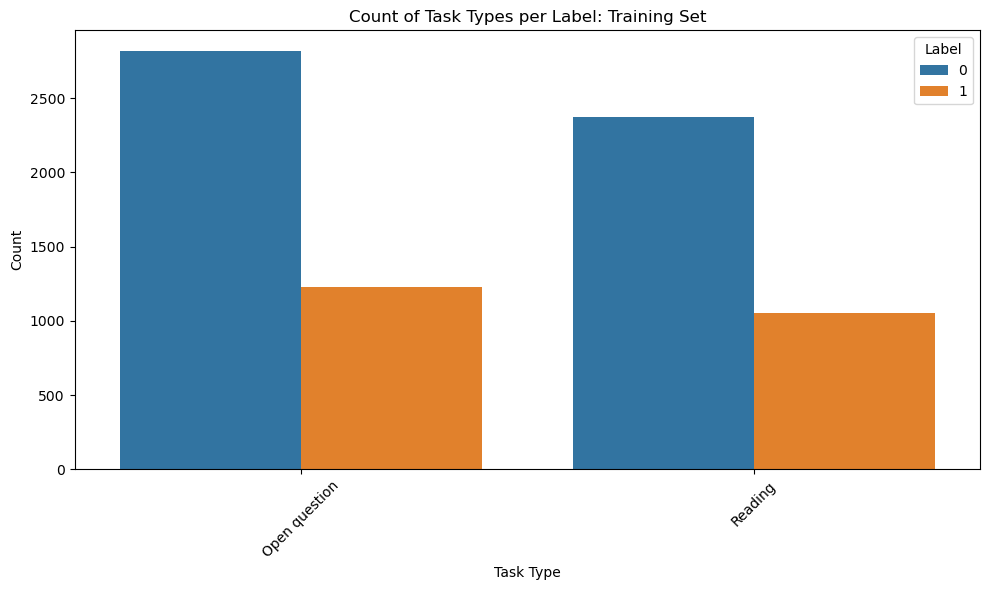


COUNT OF TYPE OF TASK ACCORDING TO TASK SET
Task Set           Type   DRUNK   SOBER
0         Open question  1335.0  2712.0
1               Reading  1146.0  2277.0


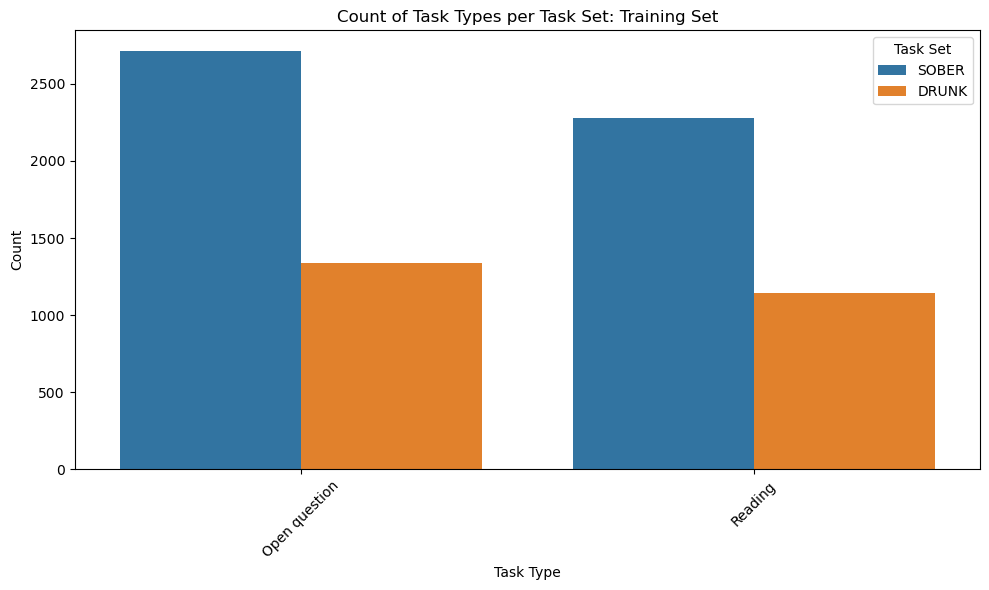


COUNT OF SUBTYPE OF TASK ACCORDING TO LABEL
Label           Type                Subtype       0      1
0      Open question      Describe an image  1351.0  584.0
1      Open question        Issue a command   591.0  268.0
2      Open question           Tell a story   875.0  378.0
3            Reading        Rapid word list   130.0  113.0
4            Reading         Read a command   377.0  113.0
5            Reading   Read a license plate   123.0   54.0
6            Reading          Read a number   500.0  221.0
7            Reading     Read a temperature    61.0   51.0
8            Reading  Read a tongue twister   497.0  170.0
9            Reading        Read an address   619.0  274.0
10           Reading           Spell a word    65.0   55.0


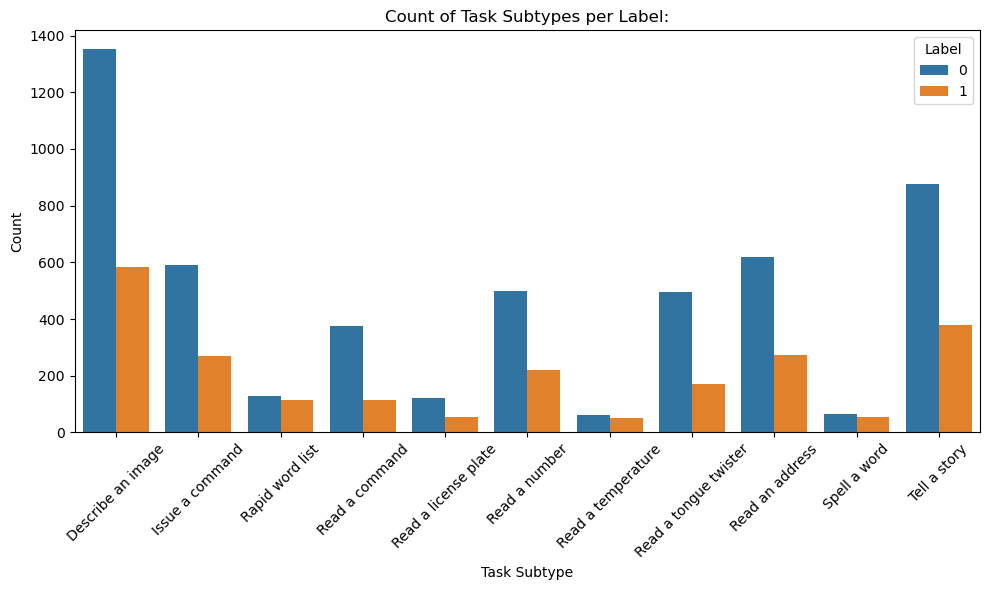


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
Task Set           Type                Subtype  DRUNK   SOBER
0         Open question      Describe an image  633.0  1302.0
1         Open question        Issue a command  292.0   567.0
2         Open question           Tell a story  410.0   843.0
3               Reading        Rapid word list  123.0   120.0
4               Reading         Read a command  123.0   367.0
5               Reading   Read a license plate   59.0   118.0
6               Reading          Read a number  241.0   480.0
7               Reading     Read a temperature   56.0    56.0
8               Reading  Read a tongue twister  185.0   482.0
9               Reading        Read an address  299.0   594.0
10              Reading           Spell a word   60.0    60.0


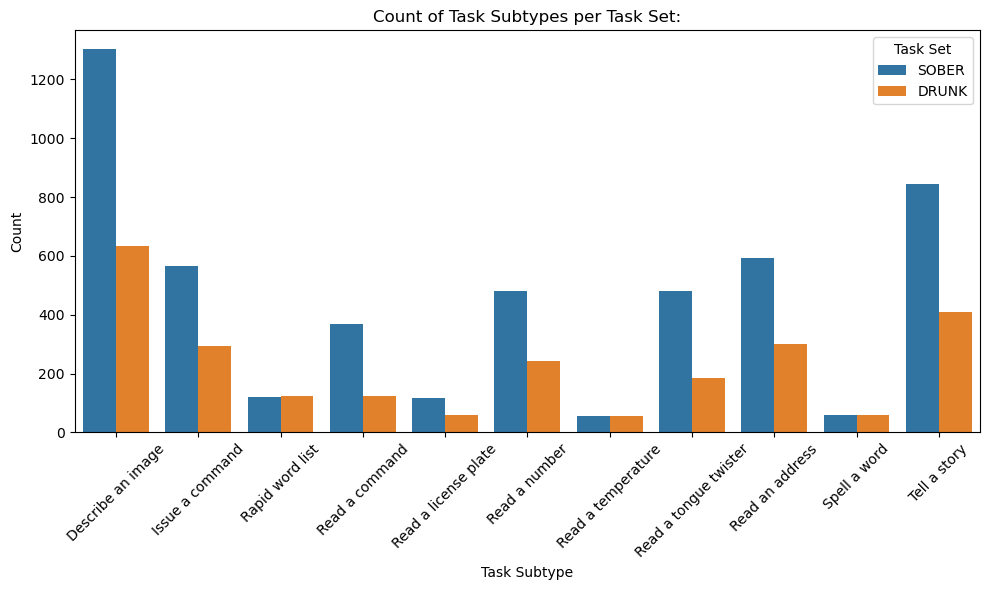

In [71]:
count_type_label(merged_dfTrain,"Training Set")
count_type_sublabel(merged_dfTrain,"Training Set")

TEST SET

COUNT OF TYPE OF TASK ACCORDING TO LABEL
Label           Type       0      1
0      Open question  1171.0  979.0
1            Reading  1016.0  879.0


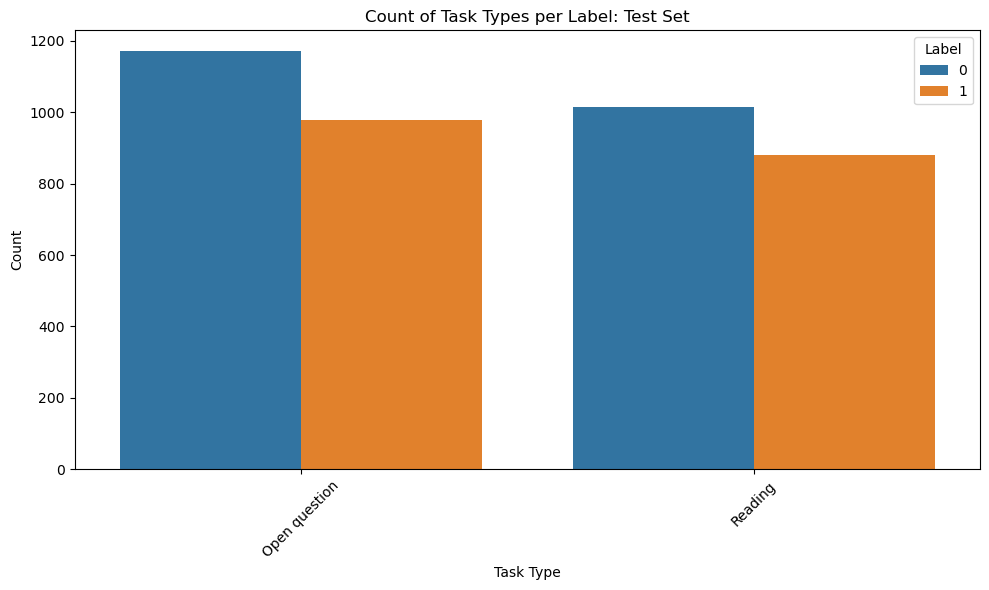


COUNT OF TYPE OF TASK ACCORDING TO TASK SET
Task Set           Type   DRUNK   SOBER
0         Open question  1068.0  1082.0
1               Reading   955.0   940.0


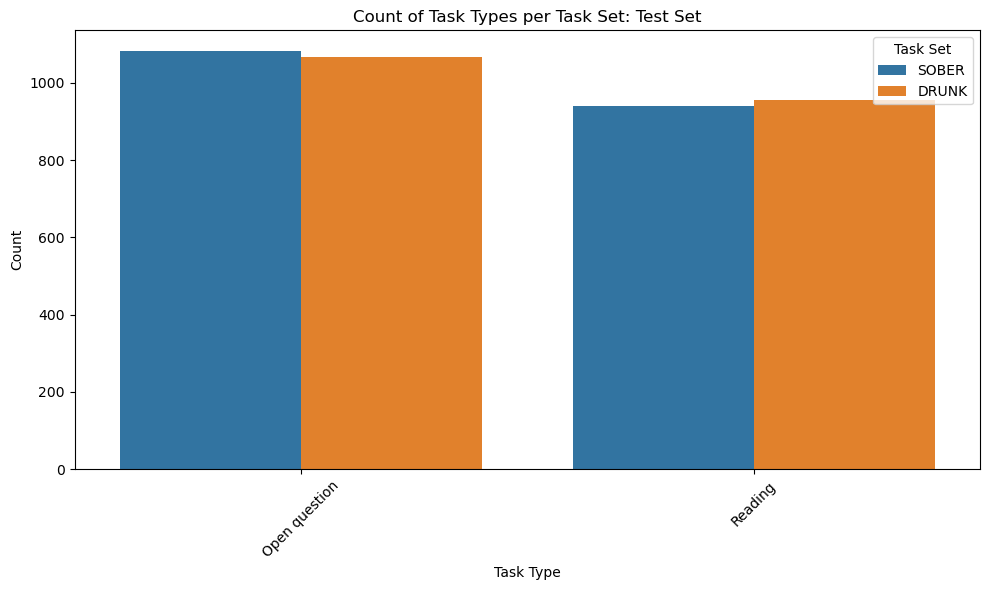


COUNT OF SUBTYPE OF TASK ACCORDING TO LABEL
Label           Type                Subtype      0      1
0      Open question      Describe an image  580.0  487.0
1      Open question        Issue a command  256.0  211.0
2      Open question           Tell a story  335.0  281.0
3            Reading        Rapid word list  108.0   95.0
4            Reading         Read a command  101.0   92.0
5            Reading   Read a license plate   54.0   46.0
6            Reading          Read a number  216.0  184.0
7            Reading     Read a temperature   52.0   43.0
8            Reading  Read a tongue twister  162.0  140.0
9            Reading        Read an address  269.0  231.0
10           Reading           Spell a word   54.0   48.0


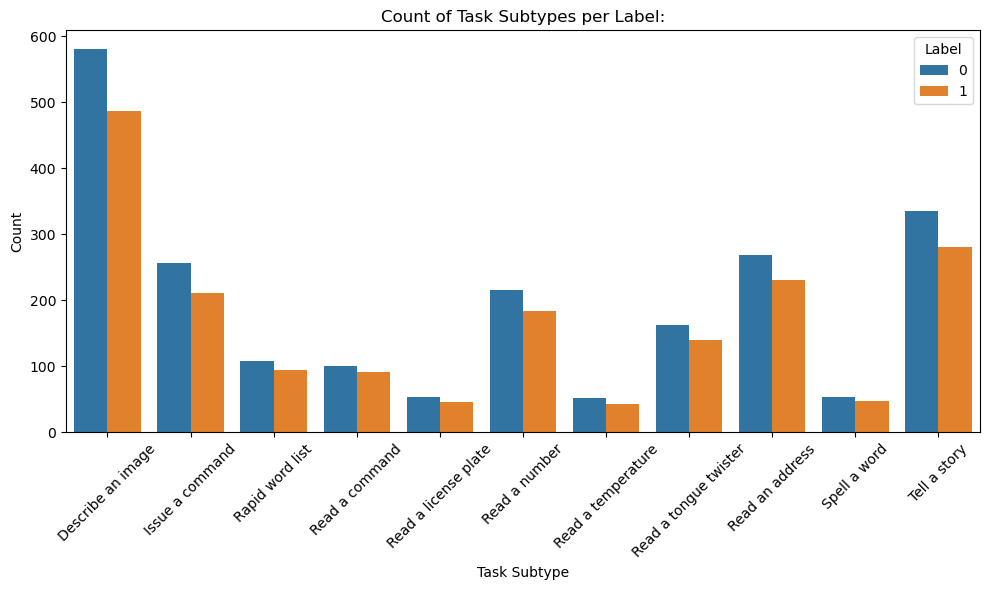


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
Task Set           Type                Subtype  DRUNK  SOBER
0         Open question      Describe an image  532.0  535.0
1         Open question        Issue a command  231.0  236.0
2         Open question           Tell a story  305.0  311.0
3               Reading        Rapid word list  103.0  100.0
4               Reading         Read a command  100.0   93.0
5               Reading   Read a license plate   50.0   50.0
6               Reading          Read a number  200.0  200.0
7               Reading     Read a temperature   47.0   48.0
8               Reading  Read a tongue twister  152.0  150.0
9               Reading        Read an address  251.0  249.0
10              Reading           Spell a word   52.0   50.0


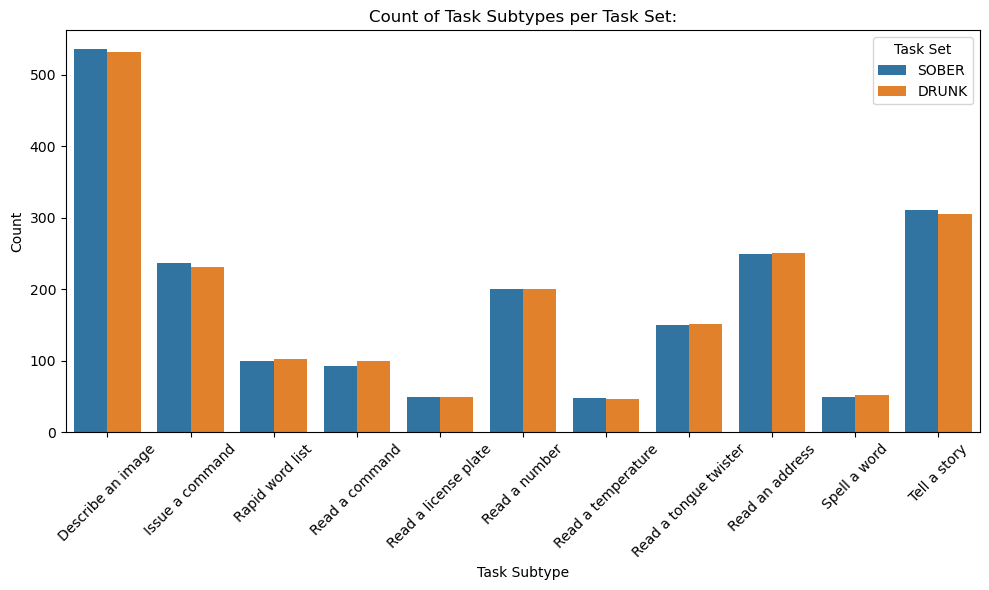

In [72]:
count_type_label(merged_dfTest,"Test Set")
count_type_sublabel(merged_dfTest,"Test Set")

VALIDATION SET

COUNT OF TYPE OF TASK ACCORDING TO LABEL
Label           Type       0      1
0      Open question  2009.0  831.0
1            Reading  1732.0  742.0


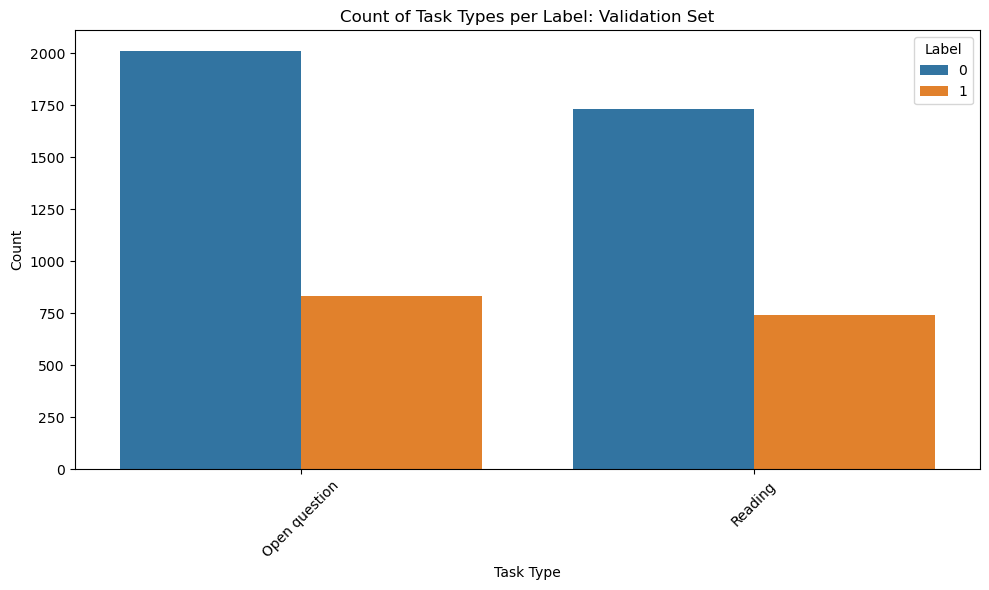


COUNT OF TYPE OF TASK ACCORDING TO TASK SET
Task Set           Type  DRUNK   SOBER
0         Open question  918.0  1922.0
1               Reading  837.0  1637.0


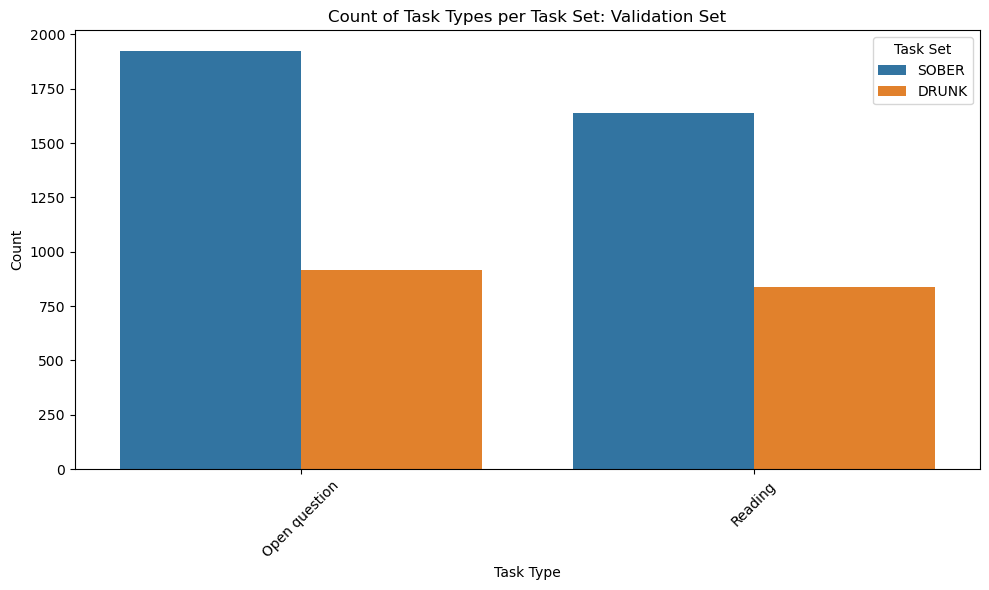


COUNT OF SUBTYPE OF TASK ACCORDING TO LABEL
Label           Type                Subtype      0      1
0      Open question      Describe an image  958.0  401.0
1      Open question        Issue a command  418.0  188.0
2      Open question           Tell a story  633.0  242.0
3            Reading        Rapid word list   98.0   78.0
4            Reading         Read a command  256.0   80.0
5            Reading   Read a license plate   93.0   39.0
6            Reading          Read a number  372.0  156.0
7            Reading     Read a temperature   42.0   38.0
8            Reading  Read a tongue twister  368.0  117.0
9            Reading        Read an address  454.0  194.0
10           Reading           Spell a word   49.0   40.0


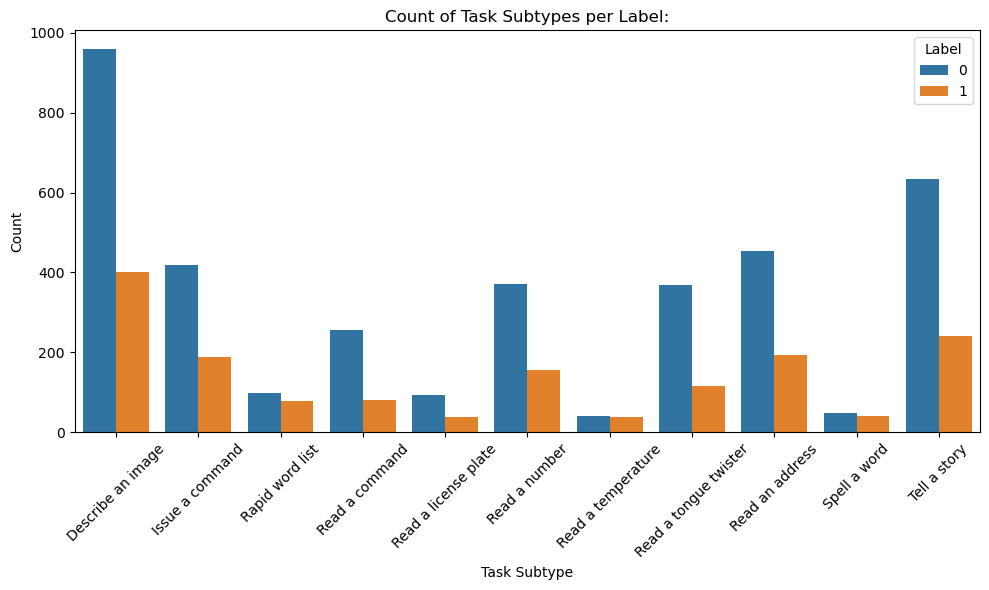


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
Task Set           Type                Subtype  DRUNK  SOBER
0         Open question      Describe an image  443.0  916.0
1         Open question        Issue a command  207.0  399.0
2         Open question           Tell a story  268.0  607.0
3               Reading        Rapid word list   88.0   88.0
4               Reading         Read a command   90.0  246.0
5               Reading   Read a license plate   44.0   88.0
6               Reading          Read a number  176.0  352.0
7               Reading     Read a temperature   43.0   37.0
8               Reading  Read a tongue twister  132.0  353.0
9               Reading        Read an address  219.0  429.0
10              Reading           Spell a word   45.0   44.0


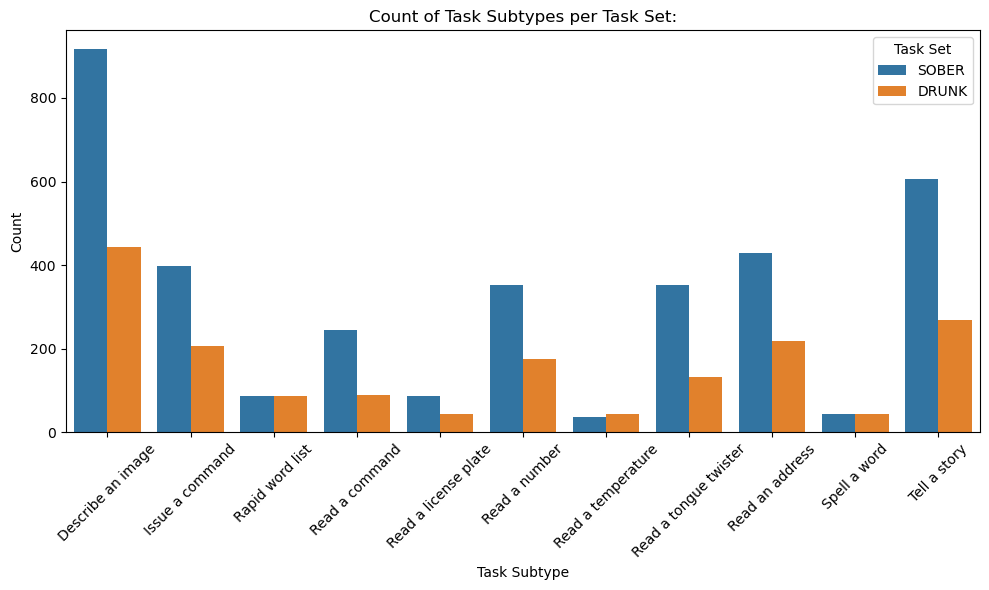

In [73]:
count_type_label(merged_dfVal,"Validation Set")
count_type_sublabel(merged_dfVal,"Validation Set")

In [79]:
# Set display options
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # No limit on line width
pd.set_option('display.max_colwidth', None)  # Show full column content


print("\nCOUNT OF TYPE OF TASK ACCORDING TO TASK ID")
type_counts = merged_dfTrain.groupby(['Subtype','Merge ID','Task Set']).size().reset_index(name='Count')
pivot_type_counts = type_counts.pivot_table(index=['Subtype','Merge ID'], columns='Task Set', values='Count', 
                                            fill_value=0).reset_index()
print(pivot_type_counts)





COUNT OF TYPE OF TASK ACCORDING TO TASK ID
Task Set                Subtype  Merge ID  DRUNK  SOBER
0             Describe an image         5    0.0  191.0
1             Describe an image        10  244.0  243.0
2             Describe an image        18    0.0  196.0
3             Describe an image        25    0.0  251.0
4             Describe an image        30  197.0  216.0
5             Describe an image        38  192.0  205.0
6               Issue a command        42   63.0   60.0
7               Issue a command        43    0.0   60.0
8               Issue a command        45    0.0   54.0
9               Issue a command        46   61.0   58.0
10              Issue a command        47    0.0   59.0
11              Issue a command        48   44.0   46.0
12              Issue a command        49   61.0   59.0
13              Issue a command        53    0.0   55.0
14              Issue a command        54    0.0   58.0
15              Issue a command        55   63.0   58.0
16  